# 1. Import Libraries

In [ ]:
# importing numpy for array handling and numerical operations
import numpy as np
# loading OpenCV because I need it for reading the images (especially in grayscale)
import cv2
# matplotlib is just for plotting the images to see what's going on
import matplotlib.pyplot as plt
# mutual_info_score gives me MI based on the joint histogram
from sklearn.metrics import mutual_info_score

# 2. Loading and Displaying the Images

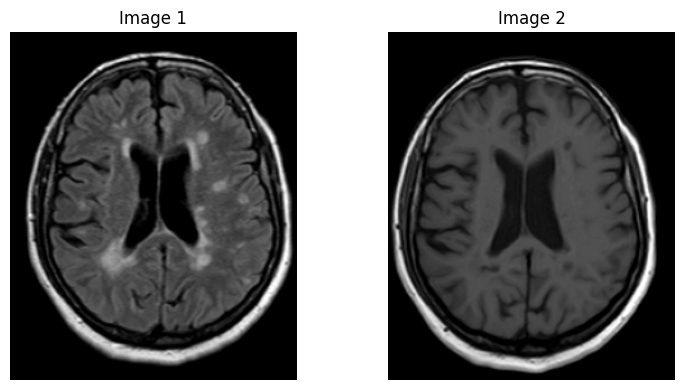

In [ ]:
# specifying the paths to the two images I'm going to compare
path_img1 = "HW04-F1.png"
path_img2 = "HW04-F2.png"
# reading the images in grayscale and converting them to float32 for consistency
img1 = cv2.imread(path_img1, cv2.IMREAD_GRAYSCALE).astype(np.float32)
img2 = cv2.imread(path_img2, cv2.IMREAD_GRAYSCALE).astype(np.float32)
# setting up a figure just to show both images next to each other
plt.figure(figsize=(8,4))
# plotting the first image
plt.subplot(1,2,1)
plt.title("Image 1")
plt.imshow(img1, cmap="gray")
plt.axis("off")
# plotting the second image
plt.subplot(1,2,2)
plt.title("Image 2")
plt.imshow(img2, cmap="gray")
plt.axis("off")
# fixing the spacing so plots don't overlap
plt.tight_layout()
# finally showing the two images
plt.show()

# 3. Mutual Information Function
I'm writing my own MI function instead of using the library one. Basically I'm normalizing the images, creating a joint histogram, converting it to probabilities, and then computing MI from the definition.

In [ ]:
# defining a function to compute mutual information manually
def compute_mi(im1, im2, bins=64):
    # flattening both images so I can treat them as 1D arrays
    x = im1.ravel().astype(np.float32)
    y = im2.ravel().astype(np.float32)
    # normalizing the pixel values to [0, 1] to avoid issues with range differences
    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)
    # converting normalized values into discrete bin indices
    x_bins = (x_norm * (bins - 1)).astype(int)
    y_bins = (y_norm * (bins - 1)).astype(int)
    # creating an empty joint histogram
    joint_hist = np.zeros((bins, bins), dtype=np.float64)
    # filling the joint histogram by counting occurrences of each (x_bin, y_bin) pair
    for xb, yb in zip(x_bins, y_bins):
        joint_hist[xb, yb] += 1
    # turning the histogram into a joint probability distribution
    joint_prob = joint_hist / joint_hist.sum()
    # marginal distributions for X and Y
    p_x = joint_prob.sum(axis=1)         # sum over columns
    p_y = joint_prob.sum(axis=0)         # sum over rows
    # outer product to get p(x)*p(y)
    px_py = p_x[:, None] * p_y[None, :]
    # tiny constant so I don't take log(0)
    eps = 1e-12
    # mask to avoid zero entries
    mask = joint_prob > 0
    # computing mutual information using the definition
    mi = np.sum(joint_prob[mask] * (np.log(joint_prob[mask] + eps) - np.log(px_py[mask] + eps)))
    return mi

# 4. Initial MI Before Registration
I'm matching the two images to the same size, taking the overlapping region, and computing the mutual information before doing any registration.

In [ ]:
# number of bins I want to use for the joint histogram
bins = 64
# making sure both images have the same height and width by taking the minimum
h = min(img1.shape[0], img2.shape[0])
w = min(img1.shape[1], img2.shape[1])
# cropping the first image to the common size
im1_init = img1[:h, :w]
# cropping the second image to the same common size
im2_init = img2[:h, :w]
# computing mutual information between the two cropped images before registration
mi_before = compute_mi(im1_init, im2_init, bins=bins)
# printing the MI value so I can compare it later with the registered case
print("MI (before registration) =", mi_before)

MI (before registration) = 0.37433390227744684


# 5. Exhaustive Translation Search for Registration
In this part I'm doing a brute-force search over possible translations in x and y. For each shift, I move the second image, compute the mutual information with the first one, and keep the shift that gives the highest MI as the best registration.

In [ ]:
# defining the search range for translation in x and y directions (in pixels)
tx_min, tx_max = -15, 15
ty_min, ty_max = -15, 15

# initializing the best MI with minus infinity so any real value will be better
best_mi = -np.inf

# variables to store the best translation parameters
best_tx, best_ty = 0, 0

# variable to store the best registered version of img2
best_registered = None

# getting the shape of the second image (used for warpAffine output size)
rows, cols = img2.shape

# looping over all possible translations in x
for tx in range(tx_min, tx_max + 1):
    # and for each x, looping over all possible translations in y
    for ty in range(ty_min, ty_max + 1):

        # building the 2x3 affine transformation matrix for pure translation
        M = np.float32([[1, 0, tx],
                        [0, 1, ty]])

        # applying the translation to img2
        moved = cv2.warpAffine(
            img2, M, (cols, rows),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )
        # computing the overlapping region between img1 and the moved image
        h = min(img1.shape[0], moved.shape[0])
        w = min(img1.shape[1], moved.shape[1])
        im1 = img1[:h, :w]
        im2 = moved[:h, :w]
        # computing MI for this particular translation
        mi_val = compute_mi(im1, im2, bins=bins)
        # if this MI is better than what I had before, I update the best values
        if mi_val > best_mi:
            best_mi = mi_val
            best_tx, best_ty = tx, ty
            best_registered = moved.copy()
# printing the best translation found
print("Best translation: tx =", best_tx, ", ty =", best_ty)
# printing the MI after registration (i.e., using the best translation)
print("MI (after registration) =", best_mi)

Best translation: tx = 12 , ty = -7
MI (after registration) = 0.8316525419430852


# 6. Visualization of Fixed, Moving, and Registered Images

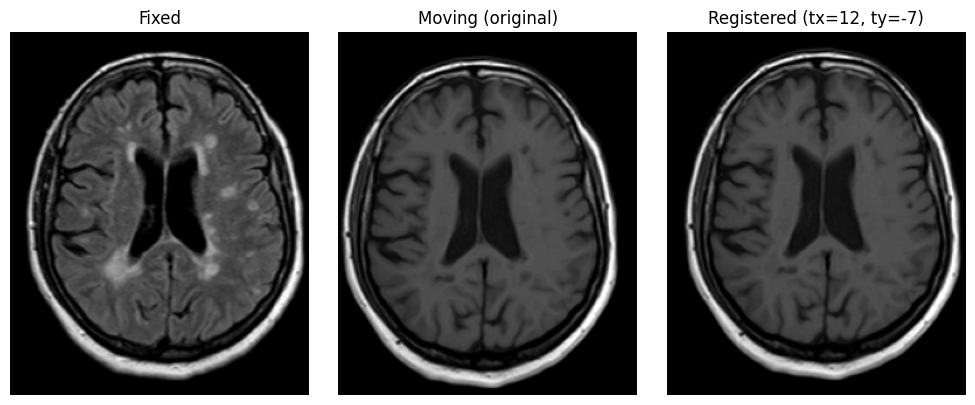

In [ ]:
# creating a figure to display all three images next to each other
plt.figure(figsize=(10, 4))
# showing the fixed/reference image
plt.subplot(1, 3, 1)
plt.title("Fixed")
plt.imshow(img1, cmap="gray")
plt.axis("off")
# showing the original moving image before registration
plt.subplot(1, 3, 2)
plt.title("Moving (original)")
plt.imshow(img2, cmap="gray")
plt.axis("off")
# showing the best registered version after finding the optimal translation
plt.subplot(1, 3, 3)
plt.title(f"Registered (tx={best_tx}, ty={best_ty})")
plt.imshow(best_registered, cmap="gray")
plt.axis("off")
# adjusting layout so plots don’t overlap
plt.tight_layout()
# displaying the final visualization
plt.show()

# 7. MI Using sklearn
I'm computing mutual information using sklearn’s mutual_info_score. I first normalize both images, quantize them into bins, and then feed the flattened arrays into the function.

In [ ]:
# defining a helper function to compute MI using sklearn's mutual_info_score
def mi_sklearn(img1, img2, bins=64):
    # converting both images to float32 just to keep things consistent
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    # normalizing both images to the [0, 1] range
    img1 = (img1 - img1.min()) / (img1.max() - img1.min() + 1e-12)
    img2 = (img2 - img2.min()) / (img2.max() - img2.min() + 1e-12)
    # quantizing the pixel values into discrete bins
    img1_q = (img1 * (bins - 1)).astype(np.int32)
    img2_q = (img2 * (bins - 1)).astype(np.int32)
    # computing MI by comparing the two quantized arrays
    return mutual_info_score(img1_q.ravel(), img2_q.ravel())

# 8. Comparing Manual MI vs sklearn MI

In [ ]:
# computing MI using my own manual MI implementation
mi_manual_before = compute_mi(im1_init, im2_init, bins=bins)
# computing MI using sklearn's built-in mutual_info_score method
mi_sklearn_before = mi_sklearn(im1_init, im2_init, bins=bins)

# 9. MI After Registration

In [ ]:
# assigning the best registered image (just to keep the naming consistent)
im1_reg = best_registered
# MI after registration based on my manual implementation (already computed as best_mi)
mi_manual_after = best_mi
# computing MI after registration using sklearn's method
mi_sklearn_after = mi_sklearn(im1_reg, im1_init, bins=bins)

# 10. MI Comparison Plot

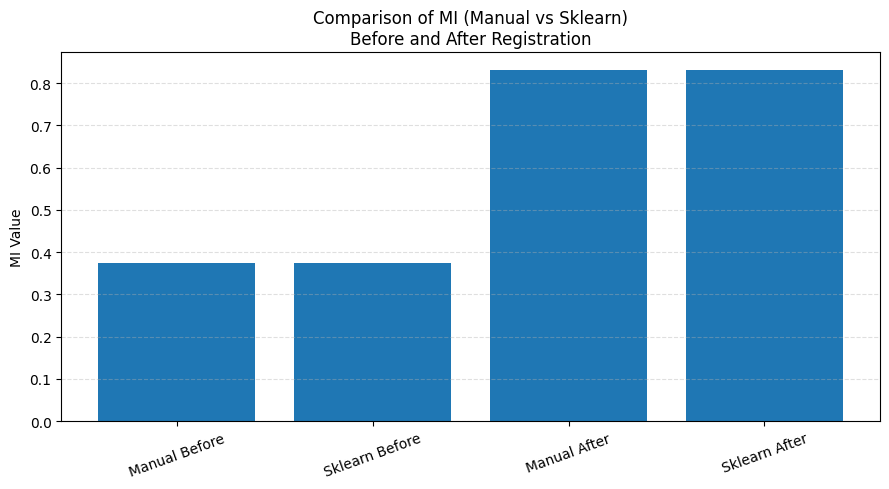

In [ ]:
# labels for the bar chart so I can distinguish each MI value
labels = ["Manual Before", "Sklearn Before", "Manual After", "Sklearn After"]
# corresponding MI values gathered from earlier computations
values = [mi_manual_before, mi_sklearn_before, mi_manual_after, mi_sklearn_after]
# creating a figure for the bar plot
plt.figure(figsize=(9,5))
# plotting the bars
plt.bar(labels, values)
# adding a title to explain what the plot represents
plt.title("Comparison of MI (Manual vs Sklearn)\nBefore and After Registration")
# labeling the y-axis
plt.ylabel("MI Value")
# rotating x-labels a bit so they don’t overlap
plt.xticks(rotation=20)
# adding a faint horizontal grid to make reading values easier
plt.grid(axis='y', linestyle='--', alpha=0.4)
# tightening layout to avoid cutoff
plt.tight_layout()
# finally showing the plot
plt.show()